# Time Series Analyses

In [2]:
# Install it
# !pip install prophet 
# !pip install statsmodels

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.arima_model import ARMA, ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import math
from math import sqrt

import warnings
warnings.filterwarnings("ignore")

## Preprocessing

In [4]:
data = pd.read_csv("data.csv")

data.head()

,Date,Time,Energy_Consumption
0,01.01.2017,00:00,27223.06
1,01.01.2017,01:00,25825.90
2,01.01.2017,02:00,24252.68
3,01.01.2017,03:00,22915.47
4,01.01.2017,04:00,22356.99


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51120 entries, 0 to 51119
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                51120 non-null  object 
 1   Time                51120 non-null  object 
 2   Energy_Consumption  51120 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.2+ MB


In [6]:
# create a copy of the data and assign to df variable:

df = data.copy()

# make the columns names readable and convert the datetime format:

df['Date'] =pd.to_datetime(df['Date'] +' '+ df['Time'], format='%d.%m.%Y %H:%M')

df = df.drop(columns = ["Time"])

df.head()

,Date,Energy_Consumption
0,2017-01-01 00:00:00,27223.06
1,2017-01-01 01:00:00,25825.90
2,2017-01-01 02:00:00,24252.68
3,2017-01-01 03:00:00,22915.47
4,2017-01-01 04:00:00,22356.99


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51120 entries, 0 to 51119
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                51120 non-null  datetime64[ns]
 1   Energy_Consumption  51120 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 798.9 KB


In [8]:
# Resampling hourly frequency data to daily frequency, 
# Setting the 'Date' column as the index and assigning it to the variable 'data_daily':
# Since we are working with time series data, we set the 'Date' column as the index as well.

data_daily= df.set_index("Date").resample('D').sum() #Sum of the values in the related day
data_daily.head()

,Energy_Consumption
Date,
2017-01-01,650391.87
2017-01-02,795405.15
2017-01-03,834470.27
2017-01-04,846016.81
2017-01-05,842624.48


In [9]:
# Export daily data to folder
data_daily.to_csv('daily_data.csv', index=True)

In [10]:
data_daily.describe()

,Energy_Consumption
count,2.130000e+03
mean,8.279211e+05
std,9.700302e+04
min,4.572721e+05
25%,7.657200e+05
50%,8.285861e+05
75%,8.919092e+05
max,1.148473e+06


In [11]:
# null values check :
# no null values


data_daily.isnull().sum()

Energy_Consumption    0
dtype: int64

In [12]:
# duplicate check:
# 3 duplicates

duplicate = data_daily[data_daily.duplicated()]
 
print("Duplicate Rows :")
duplicate

Duplicate Rows :


,Energy_Consumption
Date,


In [13]:
# dropping the duplicate values: 

data_daily.drop_duplicates(inplace=True)

In [14]:
# check again after the drop: 

duplicate = data_daily[data_daily.duplicated()]
 
print("Duplicate Rows :")
duplicate

Duplicate Rows :


,Energy_Consumption
Date,


In [15]:
# Our current "daily_data". 
# we assigned Date to Index. 
data_daily.head(2)

,Energy_Consumption
Date,
2017-01-01,650391.87
2017-01-02,795405.15


# Lineplot of the data

## Visualize the detection of Trend and Seasonality

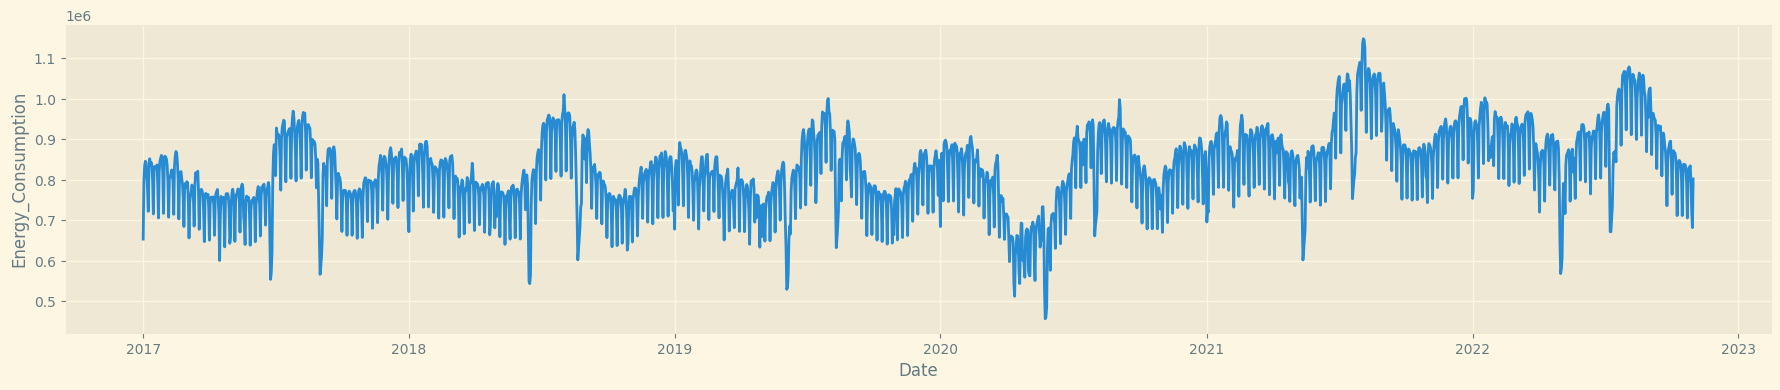

In [16]:
# visualizing the data over the line plot:

plt.figure(figsize=(22,4))
sns.lineplot(data = data_daily.reset_index(), x="Date", y="Energy_Consumption");

* As you can see, there are a strong seasonality and a weak trend in this series. 

## Components of time series: 

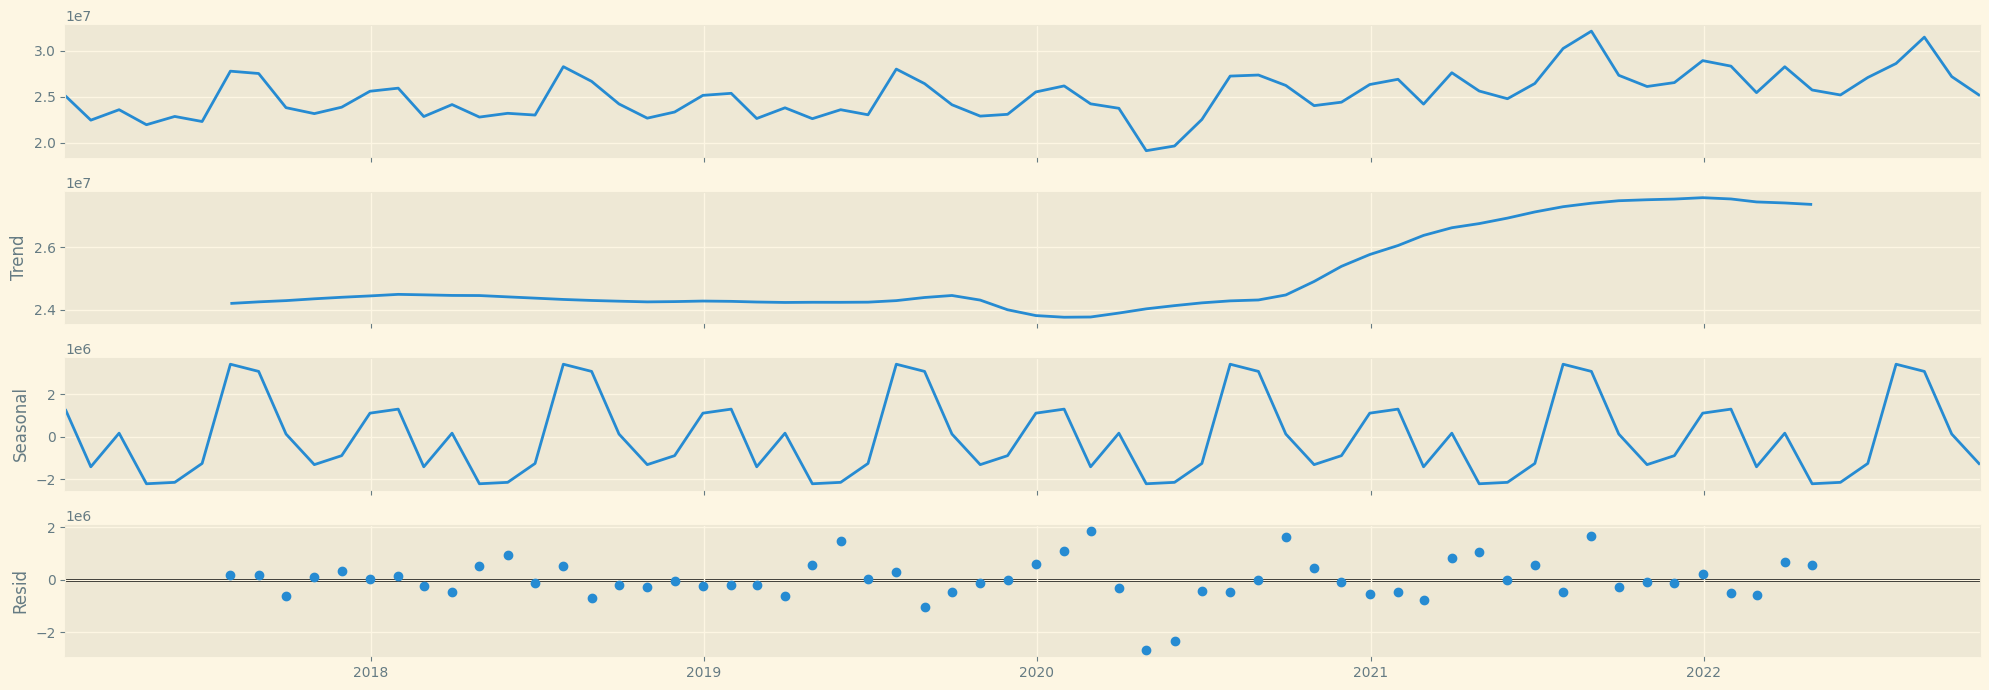

In [17]:
# Transform hourly data to monthly data by summing values for each month (since we couldn't see seasonality at daily data.)
data_monthly = df.set_index("Date").resample('M').sum()

plt.rcParams['figure.figsize'] = [20,7]
decomposition = sm.tsa.seasonal_decompose(data_monthly)
fig = decomposition.plot()
plt.show()

**Interpretation of the graph:** We can say that electricity consumption data, especially after 2020, has a general positive trend and seasonality. Energy consumption values peak in the summer months and experience a sharp decline in the fall followed by a slight increase until the winter season, and then gradually decrease throughout the spring.

* Since our data have seasonality and trend, it is not stationary.

* We should look ACF and PACF graphs.

# ACF & PACF Graphics/Visuals

In [18]:
# If the data is not stationary, we can make inferences about the stationarity of the series by checking these graphs. 
# In time series analysis, examining the autocorrelation and partial autocorrelation plots is an important step. 
# We will use the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to determine the number of model terms."

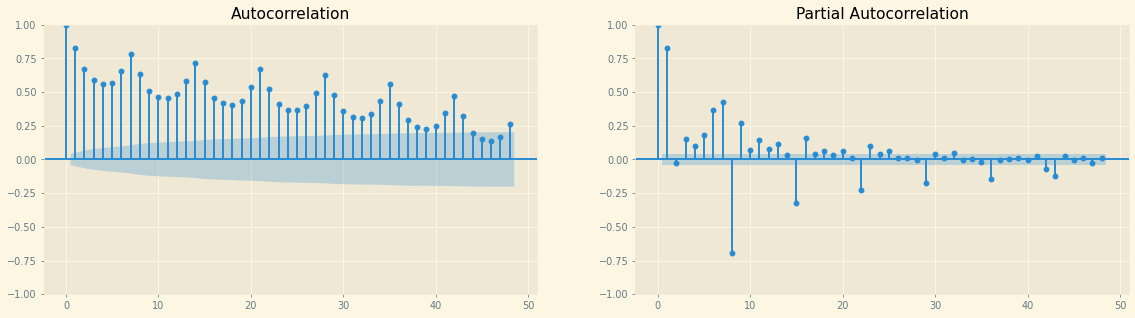

In [19]:
# the autocorrelation and partial autocorrelation visuals(ACF-PACF): 

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,5), dpi= 70)

plot_acf(data_daily.Energy_Consumption.tolist(), ax=ax1, lags=48)
plot_pacf(data_daily.Energy_Consumption.tolist(), ax=ax2, lags=48, method="ywm")

plt.show()

- The information obtained from ACF and PACF graphs is important in the modelling phase.

- If the ACF graph decreases slowly and approaches 0, it indicates the AR model.

- If the ACF chart shows a sharp decline at lag 1 and then approaches 0, this indicates the MA pattern.

- If the PACF chart shows a sharp decline at a lag (i.e. p) later and then approaches 0, this indicates the AR pattern. -->**AR(p)**

- If the PACF chart is slowly decreasing and approaching 0, this indicates an MA pattern.

* The blue shadow graph seen in these graphs is the **confidence interval**. It is used to determine whether autocorrelations are significant or not. If autocorrelation values out of that blue zone, they are significiant as statistical. 


* If there is a pattern that repeats at specific intervals in the ACF and PACF graphs, this indicates **seasonality**.


* **While the autocorrelation slows down in the ACF graph and sharply decreases after a certain lag in the PACF graph, this usually indicates that the series is not stationary. For such a series, the difference operation can make it stationary.** 


* **Component graphs and ACF-PACF showed us that the series is not stationary.**



## Statinoarity Tests

In [20]:
# Based on the line graph of the data, time series components, and ACF-PACF plots, we can say that the series is not stationary.

"To verify these visual detections of stationarity (due to trend and seasonality), the Dickey-Fuller and KPSS hypothesis tests are used:

1- Augmented Dickey-Fuller Test
* Null Hypothesis H0: The series is non-stationary (has a unit root)
* Alternative Hypothesis H1: The series is stationary (no unit root)

2- Kwiatkowski-Phillips-Schmidt-Shin Test
* Null Hypothesis H0: The series is stationary (no unit root)
* Alternative Hypothesis H1: The series is non-stationary" (has a unit root)

In [21]:
# ADF Test:

def adf(data):
    adf_test = sm.tsa.adfuller(data, autolag='AIC')
    print(f'ADF Statistic: {adf_test[0]}')
    print(f'p-value: {adf_test[1]}')
    print("The series is non-stationary") if adf_test[1] > 0.05 else print("The series is stationary (no unit root)")

# KPSS Test:

def kpss(data):
    kpss_test = sm.tsa.kpss(data)
    print('KPSS Statistic: %f' % kpss_test[0])
    print('p-value: %f' % kpss_test[1])
    print("The series is stationary") if kpss_test[1] > 0.05 else print("The series is non-stationary (contains unit root)")

adf(data_daily)
print()
kpss(data_daily)


ADF Statistic: -3.564012745893568
p-value: 0.0064874920014456935
The series is stationary (no unit root)

KPSS Statistic: 2.304301
p-value: 0.010000
The series is non-stationary (contains unit root)


In [22]:
# Considering that the p-value is less than 0.05 (and even 0.01), 
# we can say that this time series is stationary at the 95% (and 99%) confidence level. 
# If the ADF statistic is negative, the hypothesis is rejected in favor of stationarity."

In [23]:
# If the ADF test does not find a unit root but the KPSS test does, the series is differenced stationary and differencing is still required."

In [24]:
# If even one of the tests indicates the presence of a unit root, we cannot say that the series is stationary.

"In the following section:
    After confirming that the series is not stationary, let's take the first difference of the series using the differencing method to test if the series becomes stationary.
    Additionally, other methods are available, which are mentioned in the lecture notes."

In [25]:
# First difference for making series stationary

data_daily_diff = data_daily.copy()
data_daily_diff['Energy_Consumption'] = data_daily['Energy_Consumption'] - data_daily['Energy_Consumption'].shift(1)
data_daily_diff = data_daily_diff.dropna()
data_daily_diff.head(3)

,Energy_Consumption
Date,
2017-01-02,145013.28
2017-01-03,39065.12
2017-01-04,11546.54


In [26]:
# ----------------Easier method---------------; 

data_daily_diff['Energy_Consumption'] = data_daily['Energy_Consumption'].diff() 
data_daily_diff = data_daily_diff.dropna()
data_daily_diff.head(3)

,Energy_Consumption
Date,
2017-01-02,145013.28
2017-01-03,39065.12
2017-01-04,11546.54


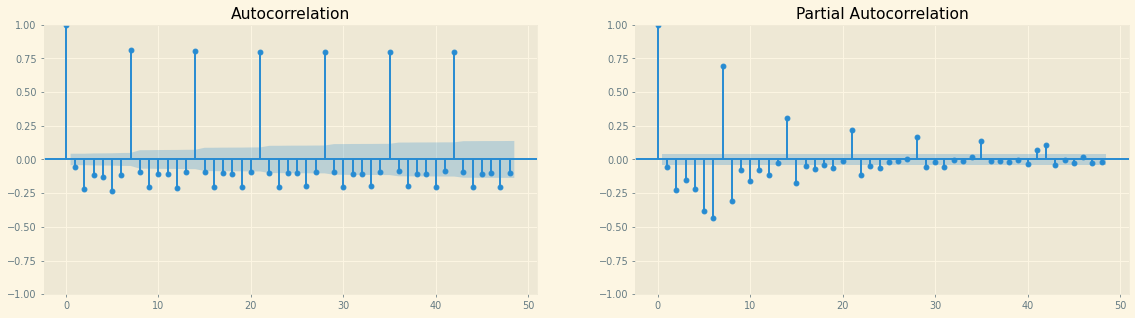

In [27]:
#  ACF and PACF plots of the series after taking the first difference:

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,5), dpi= 70)

plot_acf(data_daily_diff.Energy_Consumption.tolist(), ax=ax1, lags=48)
plot_pacf(data_daily_diff.Energy_Consumption.tolist(), ax=ax2, lags=48, method="ywm")

plt.show()

In [28]:
#  ADF-KPSS tests of the series after taking the first difference: 

adf(data_daily_diff)
print()
kpss(data_daily_diff)

ADF Statistic: -12.832566861467564
p-value: 5.831359659284965e-24
The series is stationary (no unit root)

KPSS Statistic: 0.031202
p-value: 0.100000
The series is stationary


In [29]:
# Even though our series has now become stationary, we can still observe fluctuations, indicating seasonality, in the ACF plot.
# When examining the repetitions of lag numbers, we can identify that the period is 7. 
# Additionally, we see that the 7th lag in the PACF is also outside the bounds."

In [30]:
# After determining the period as 7, we take the first-order "seasonal difference":
# Applying seasonal differencing on the series that has been differenced first-order:"

data_daily_diff2 = data_daily_diff.diff(7).dropna()

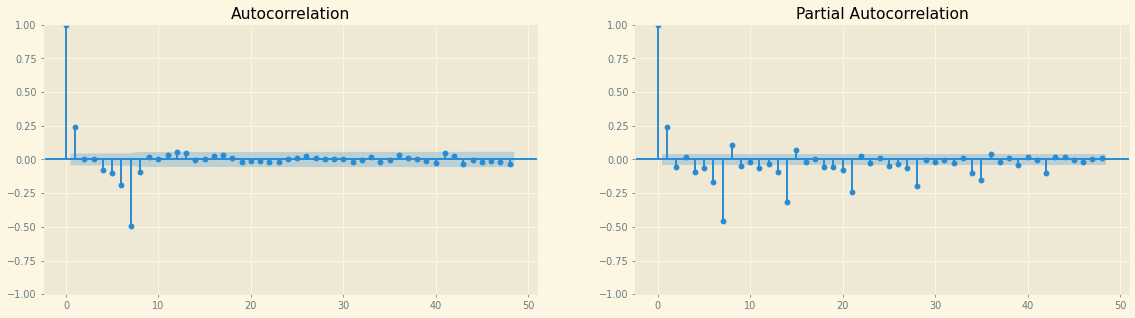

In [31]:
#  ACF & PACF plot

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,5), dpi= 70)

plot_acf(data_daily_diff2.Energy_Consumption.tolist(), ax=ax1, lags=48)
plot_pacf(data_daily_diff2.Energy_Consumption.tolist(), ax=ax2, lags=48)

plt.show()

As a result of the above operations, we have successfully removed the trend and seasonal effects from our series.

# Modelling Stage

Before moving on to the modeling phase, let’s try to manually determine the model parameters based on our analysis.

Since the series has become stationary by taking both trend and seasonal differences, we will define 
𝑑 =1 and 𝐷 =1

In the ACF plot, significant lags are observed at 1, 2, and 7. Therefore, the MA(q) parameter can be 2, and the seasonal MA(Q) parameter can be 1.

In the PACF plot, significant lags are observed at 1, 2, 7, 14, and 21. The AR(p) parameter can be 2. However, it is generally recommended to set the seasonal AR(P) parameter to 0 in this case.

Some sources suggest adding a seasonal MA(Q) term to the model and omitting the seasonal AR(P) term (setting it to 0) if the autocorrelation at seasonal lags is negative. However, since trials showed that setting AR(P)=1 provided a lower error rate and higher R-squared value, we will set the AR(P) term to 1.

Based on this, our notation will be ARIMA(2,1,2) and SARIMA(2,1,2)x(1,1,1,7).

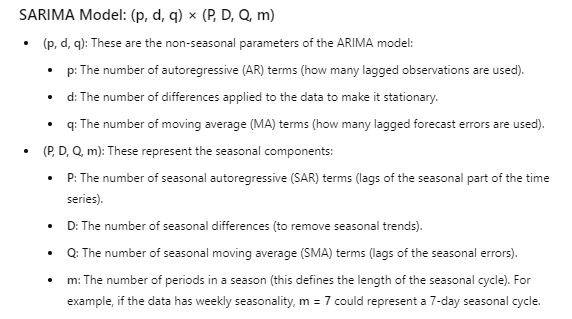

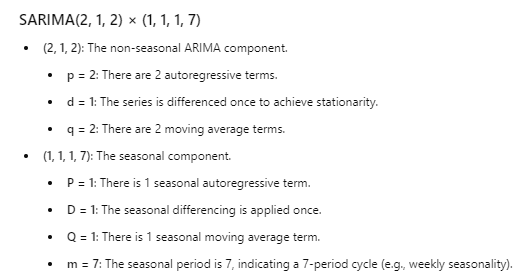

In [32]:
# Splitting the dataset into training and test sets:
# The period from January 1, 2017, to July 31, 2022, will be used as the training set, 
# and the period from August 1, 2022, to August 31, 2022, will be used as the test set."

train_data = data_daily[:'2022-07-31']
test_data = data_daily['2022-08-01':'2022-08-31']
pred_df = test_data.copy()

For each model, we will perform predictions over the same period and then compare the results with the actual values in the test set.

## ARIMA modelling

In [33]:
# Let's create the ARIMA(2,1,2) model using the statsmodels package and perform predictions for the specified period. 
# Then, we will visualize the predicted values alongside the actual values.

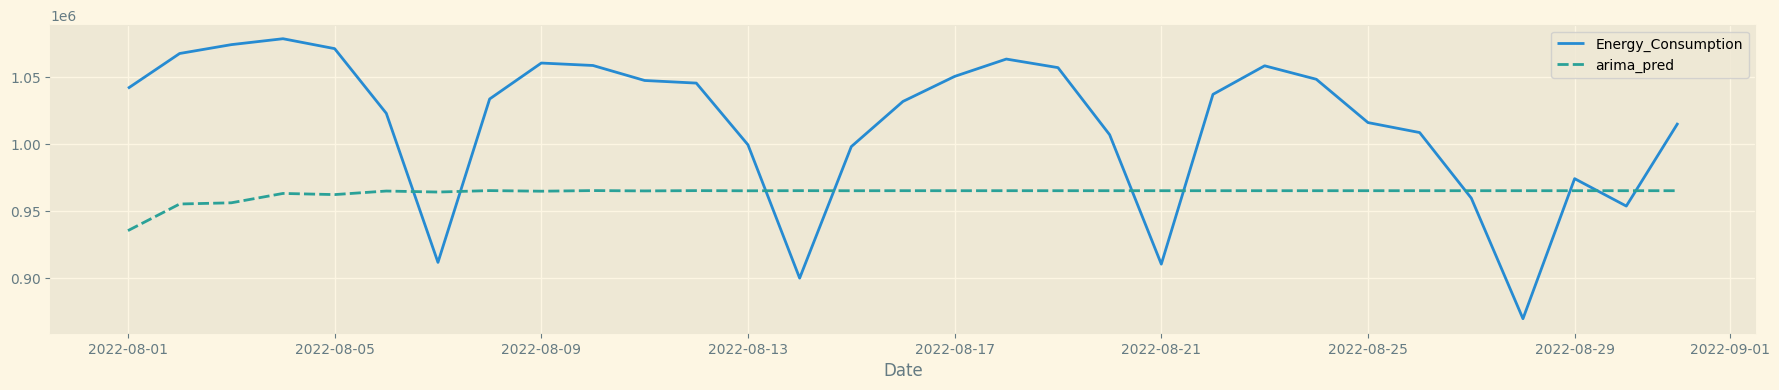

In [34]:
# ARIMA (2,1,2)
# plitting the dataset into training and test sets

arima_model = sm.tsa.arima.ARIMA(np.asarray(train_data),order=(2,1,2))
arima_model_fit = arima_model.fit()
arima_pred = arima_model_fit.forecast(len(test_data),disp=False)

pred_df["arima_pred"] = arima_pred.round(2)
plt.figure(figsize=(22,4))
sns.lineplot(data = pred_df[['Energy_Consumption', 'arima_pred']]);

The ARIMA model, as we can see from the graph, did not perform well because our data contains seasonality, which ARIMA does not handle effectively. The SARIMA model will work better in such cases.

 ## SARIMA Modelling

Let's perform the same prediction operation on SARIMA. 
SARIMA (2,1,2) (1,1,1,7)

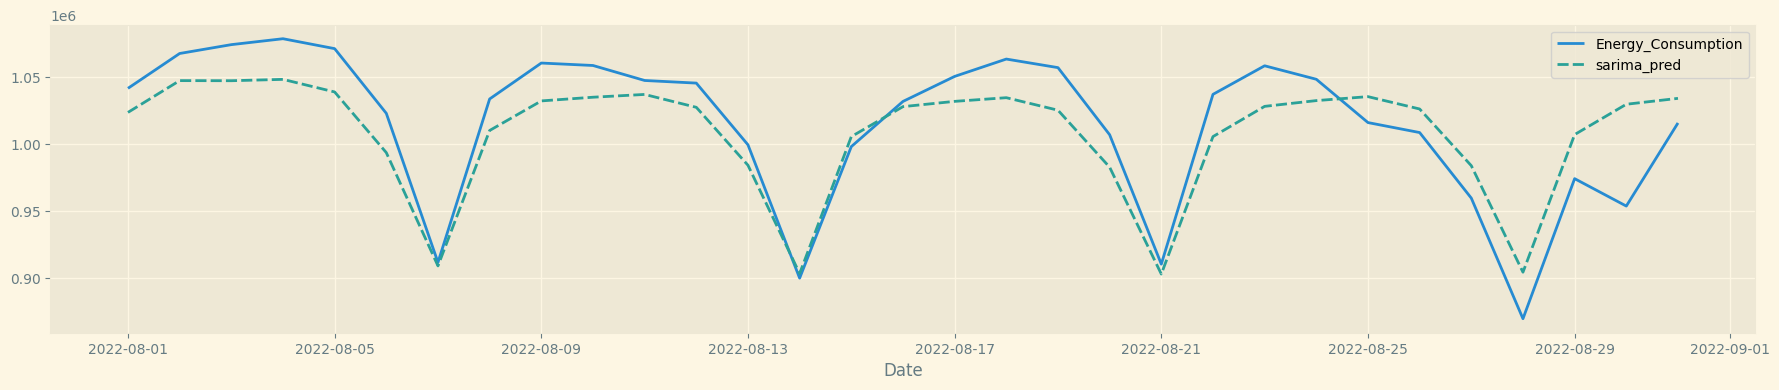

In [35]:
# SARIMA (2,1,2) (1,1,1,7)

sarima_model = SARIMAX(np.asarray(train_data), order=(2, 1, 2), seasonal_order=(1,1,1,7))
sarima_model_fit = sarima_model.fit()
sarima_pred = sarima_model_fit.forecast(len(test_data))

pred_df["sarima_pred"] = sarima_pred.round(2)
plt.figure(figsize=(22,4))
sns.lineplot(data = pred_df[['Energy_Consumption', 'sarima_pred']]);

In [36]:
# We can observe from the graph that the SARIMA model provided better results compared to the ARIMA model.

## PROPHET Modelling

In [37]:
# Since the Prophet algorithm works with 'ds' and 'y' variables as inputs, we need to adjust our training and test sets accordingly

ds: This column contains dates. For Prophet, dates in this column are typically in daily frequency, but this is not mandatory. Dates can be in YYYY-MM-DD format (e.g., "2021-01-01") or as timestamps.

y: This column contains the observed values you want to predict. For example, if you want to forecast the daily number of visitors to a website, the y column will contain these visitor counts.

In [38]:
df.tail(5)

,Date,Energy_Consumption
51115,2022-10-31 19:00:00,37907.77
51116,2022-10-31 20:00:00,36815.93
51117,2022-10-31 21:00:00,35742.46
51118,2022-10-31 22:00:00,34452.87
51119,2022-10-31 23:00:00,33006.62


12:37:53 - cmdstanpy - INFO - Chain [1] start processing
12:37:53 - cmdstanpy - INFO - Chain [1] done processing


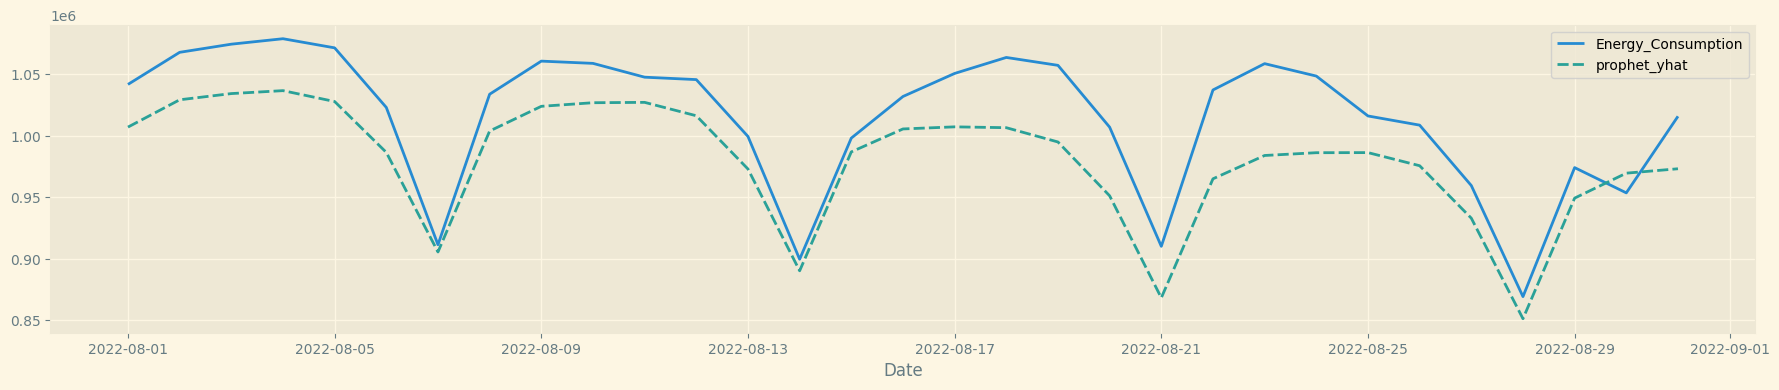

In [39]:
# PROPHET

prophet_df = data_daily.reset_index()
prophet_df.columns = ["ds","y"]

train_data_prophet = prophet_df[prophet_df['ds'] < '2022-08-01']
test_data_prophet = prophet_df[(prophet_df['ds'] >= '2022-08-01') & (prophet_df['ds'] <= '2022-08-31')]

prophet_model = Prophet()
prophet_model.fit(train_data_prophet) # fit the model on train data
model_predict = prophet_model.predict(test_data_prophet) # obtain predictions on test data

pred_df["prophet_yhat"] = model_predict["yhat"].values.round(2)
pred_df["prophet_yhat_lower"] = model_predict["yhat_lower"].values.round(2)
pred_df["prophet_yhat_upper"] = model_predict["yhat_upper"].values.round(2)

plt.figure(figsize=(22,4))
sns.lineplot(data = pred_df[['Energy_Consumption', 'prophet_yhat']]);

In [40]:
# in below we can see the visual containing yhat, yhat_lower and yhat_upper values

**yhat:** This is the main value predicted by the model. In other words, it is the value the model forecasts for the time series at a specific ds (date) value.

**yhat_lower and yhat_upper:** These values represent the uncertainty interval for the predictions. Prophet considers uncertainty when generating forecasts and estimates with high confidence that the actual value will fall within this range. For example, if yhat_lower is 50 and yhat_upper is 60, it means the model predicts with high confidence that the actual value will be within this range.

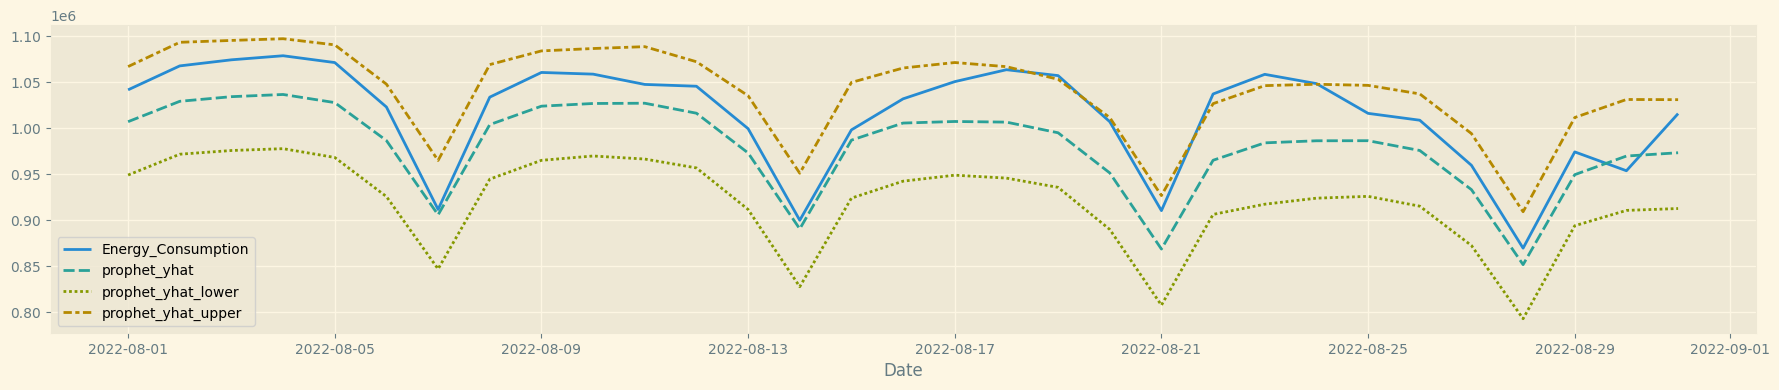

In [41]:
plt.figure(figsize=(22,4))
sns.lineplot(data = pred_df[['Energy_Consumption', 'prophet_yhat', 'prophet_yhat_lower','prophet_yhat_upper']]);

# Model Evaluation

In [42]:
# We use MAE, RMSE and R2 metrics to evaluate the model

In [43]:
print(pred_df.columns)

Index(['Energy_Consumption', 'arima_pred', 'sarima_pred', 'prophet_yhat',
       'prophet_yhat_lower', 'prophet_yhat_upper'],
      dtype='object')


In [44]:
prophet_mape = mean_absolute_percentage_error(pred_df["Energy_Consumption"].values, pred_df["prophet_yhat"].values)
prophet_r = r2_score(pred_df["Energy_Consumption"].values, pred_df["prophet_yhat"].values)
prophet_rmse = math.sqrt(mean_squared_error(pred_df["Energy_Consumption"].values, pred_df["prophet_yhat"].values))

arima_mape = mean_absolute_percentage_error(pred_df["Energy_Consumption"].values, pred_df["arima_pred"].values)
arima_r = r2_score(pred_df["Energy_Consumption"].values, pred_df["arima_pred"].values)
arima_rmse = math.sqrt(mean_squared_error(pred_df["Energy_Consumption"].values, pred_df["arima_pred"].values))

sarima_mape = mean_absolute_percentage_error(pred_df["Energy_Consumption"].values, pred_df["sarima_pred"].values)
sarima_r = r2_score(pred_df["Energy_Consumption"].values, pred_df["sarima_pred"].values)
sarima_rmse = math.sqrt(mean_squared_error(pred_df["Energy_Consumption"].values, pred_df["sarima_pred"].values))

results = {'Prophet': [prophet_mape,prophet_rmse,prophet_r], 
        'ARIMA': [arima_mape,arima_rmse,arima_r],
        'SARIMA': [sarima_mape,sarima_rmse,sarima_r]}
results = pd.DataFrame(results,index=['MAE','RMSE','R2'])
results

,Prophet,ARIMA,SARIMA
MAE,0.035244,0.068647,0.022469
RMSE,40037.875521,77054.618006,26470.706491
R2,0.478308,-0.932277,0.771964


# Conclusion/Results

"In our example, the R-squared value of the ARIMA model is -0.042, indicating that the model is not suitable for our data.

Among the models for the relevant period, the SARIMA model has the lowest RMSE and MAPE values, with an R-squared score of 0.77, which is the highest score among our models.

The results actually look surprisingly good. However, selecting a random validation period and performing a series of one-step-ahead forecasts does not mean that these models will accurately predict many future periods. Finding and validating an effective time series model is not that simple.

Here, we created our models in a very basic way and did not perform hyperparameter tuning."

"To improve SARIMA and Prophet models and reduce error rates, there are several things you can do, including correctly splitting the dataset, optimizing parameters, adding significant independent variables to the model, and incorporating holidays."


# Next Term Forecastings Using Prophet

If we would like to see forecasting for next period, we should estimate our model by using all data.

In [45]:
df = prophet_df.copy()

12:37:54 - cmdstanpy - INFO - Chain [1] start processing
12:37:54 - cmdstanpy - INFO - Chain [1] done processing


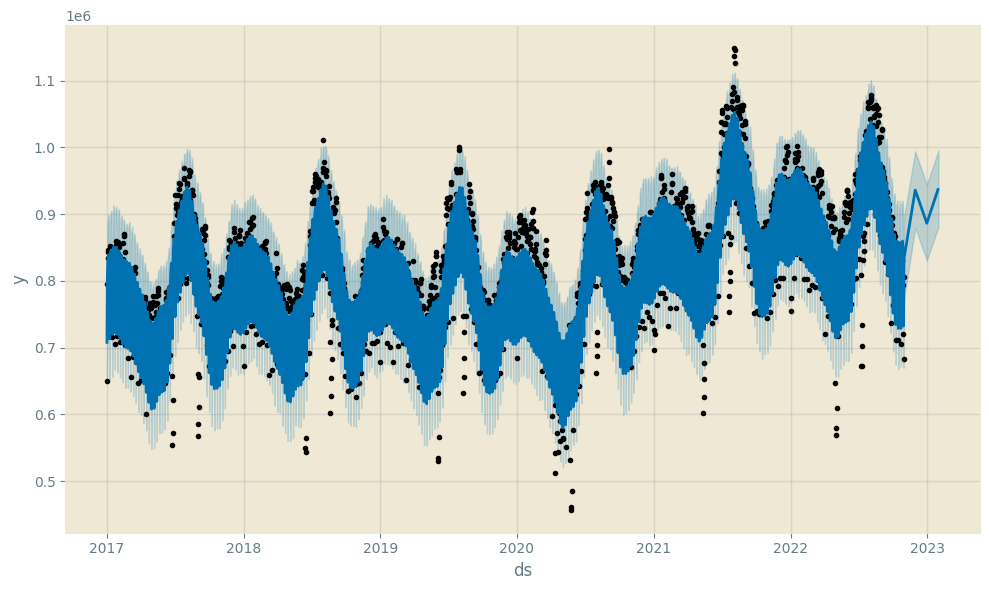

In [46]:
# Create and fit the model
model = Prophet()
model.fit(df)

# Make future predictions
future = model.make_future_dataframe(periods=3, freq='M')  # Predict for 3 months into the future
forecast = model.predict(future)

# Plot the forecast
model.plot(forecast);

In [47]:
# For see forecasted values
forecast[['ds', 'yhat']][-3:]

,ds,yhat
2130,2022-11-30,935986.439625
2131,2022-12-31,886288.891709
2132,2023-01-31,938809.381172
